In [89]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as numpy
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

# hoja de ruta:
EXPLORACION:
1) Cargamos los csv
2) Exploración básica (head, tail, sample), echar un vistazo y ver que se carga correctamente. ¿index_col = 0? --> solo si quiero que esa columna sea un indice, para eso es util echar un vistazo al df (en este caso no hace falta index_col = 0)
3) Forma csv y nombre columnas. Entender qué información contiene cada uno. 
4) Info --> tipos de datos, nombres columnas, numero de no nulos.
5) Describe numericos (medidas descriptivas media, mediana, desviacion estandar, max, min...)
6) Describe categoricos --> Recuento, numero categorias, moda y frecuencia absoluta moda. 
7) Nulos?
8) Duplicados?
(en cada fase de la exploración vamos tomando notas de los cambios que creemos que tendremos que hacer en fase de limpieza)
LIMPIEZA:
1) Homogeneizacion nombres columnas
2) Homogeneizacion categorias, decimales en flotantes...
3) Eliminar duplicados
4) Gestionar nulos
5) Unir dataframes

In [90]:
# Cargando df de Customer Flight Activity

df_flight_activity = pd.read_csv("data/customer_flight_activity.csv")
#index_col=0 solo lo pondremos si quiero añadir un nuevo índice, pero en este caso ya lo tengo

In [91]:
df_loyalty_history = pd.read_csv("data/customer_loyalty_history.csv")

#index_col=0 solo lo pondremos si quiero añadir un nuevo índice, pero en este caso ya lo tengo

In [92]:
def exploracion_basica(df):
    display(df.head(2))
    display(df.tail(2))
    display(df.sample(2))
    print(df.info())
    print(f"El dataframe {df} tiene {df.shape[0]} filas y {df.shape[1]} columnas")

In [93]:
exploracion_basica(df_flight_activity)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
306628,229436,2018,7,12,0,12,4536,453.0,0,0
108654,486776,2017,7,3,0,3,597,59.0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB
None
El dataframe         Loyalty Number  Year  Month  Flights Booked  Flights with Companions  \
0               100018  2017    

In [94]:
exploracion_basica(df_loyalty_history)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
2519,838993,Canada,Manitoba,Winnipeg,R2C 0M5,Male,Bachelor,64720.0,Single,Aurora,8311.85,Standard,2017,10,2018.0,6.0
5232,965605,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63252.0,Married,Nova,3588.88,Standard,2015,5,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

# 2) Análisis descriptivo

!! Pensar cómo hacer una función que si no encuentra un tipo de dtype (object) diga que no lo hay

In [95]:
# union dataframes
df_mergeado = df_flight_activity.merge(df_loyalty_history, how="inner", on="Loyalty Number")
df_mergeado.shape

(405624, 25)

In [96]:
df_mergeado.dtypes

Loyalty Number                   int64
Year                             int64
Month                            int64
Flights Booked                   int64
Flights with Companions          int64
Total Flights                    int64
Distance                         int64
Points Accumulated             float64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64
Country                         object
Province                        object
City                            object
Postal Code                     object
Gender                          object
Education                       object
Salary                         float64
Marital Status                  object
Loyalty Card                    object
CLV                            float64
Enrollment Type                 object
Enrollment Year                  int64
Enrollment Month                 int64
Cancellation Year              float64
Cancellation Month             float64
dtype: object

In [97]:
def analisis_descriptivo(df):
    print("NUMÉRICAS")
    display(df.describe().T)
    for i in df.dtypes:
        if i == "object":
            print("\nCATEGÓRICAS")
            return(df.describe(include="object").T)
        
    else:
        print("\n No existen datos categóricos")

In [98]:
analisis_descriptivo(df_mergeado)

NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.00,326961.00,550834.00,772194.00,999986.00
Year,405624.0,2017.500000,0.500001,2017.00,2017.00,2017.50,2018.00,2018.00
Month,405624.0,6.500000,3.452057,1.00,3.75,6.50,9.25,12.00
Flights Booked,405624.0,4.115052,5.225518,0.00,0.00,1.00,8.00,21.00
Flights with Companions,405624.0,1.031805,2.076869,0.00,0.00,0.00,1.00,11.00
Total Flights,405624.0,5.146858,6.521227,0.00,0.00,1.00,10.00,32.00
Distance,405624.0,1208.880059,1433.155320,0.00,0.00,488.00,2336.00,6293.00
Points Accumulated,405624.0,123.692721,146.599831,0.00,0.00,50.00,239.00,676.50
Points Redeemed,405624.0,30.696872,125.486049,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.00,0.00,0.00,0.00,71.00



CATEGÓRICAS


,count,unique,top,freq
Country,405624,1,Canada,405624
Province,405624,11,Ontario,130896
City,405624,29,Toronto,81096
Postal Code,405624,55,V6E 3D9,21984
Gender,405624,2,Female,203640
Education,405624,5,Bachelor,253752
Marital Status,405624,3,Married,235800
Loyalty Card,405624,3,Star,184224
Enrollment Type,405624,2,Standard,382200


In [99]:
def limpiar_columnas(df):
    nuevas_cols = {
        col: col.lower().replace(" ", "_").replace(".", "_").replace("-", "_")
        for col in df.columns
    }
    df.rename(columns=nuevas_cols, inplace=True)
    return df

In [100]:
limpiar_columnas(df_mergeado)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,12,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,5,NaN,NaN
405620,999911,2018,12,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,8,NaN,NaN
405621,999940,2018,12,3,0,3,1233,123.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,7,NaN,NaN
405622,999982,2018,12,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,7,NaN,NaN


In [101]:
def eliminar_duplicados(df):
    df = df.drop_duplicates(inplace=True) # esto es lo mismo que poner inplace=True
    return df

In [102]:
print(df_mergeado.duplicated().sum())

1864


In [103]:
eliminar_duplicados(df_mergeado)

In [104]:
print(df_mergeado.isnull().sum())

loyalty_number                      0
year                                0
month                               0
flights_booked                      0
flights_with_companions             0
total_flights                       0
distance                            0
points_accumulated                  0
points_redeemed                     0
dollar_cost_points_redeemed         0
country                             0
province                            0
city                                0
postal_code                         0
gender                              0
education                           0
salary                         102260
marital_status                      0
loyalty_card                        0
clv                                 0
enrollment_type                     0
enrollment_year                     0
enrollment_month                    0
cancellation_year              354110
cancellation_month             354110
dtype: int64


In [105]:
# TAREAS LIMPIEZA: 
# 1) HOMOGENEIZAR NOMBRE COLUMNAS --> check
# 2) CAMBIAR FECHAS () A DATETIME --> check
# 3) CAMBIAR RECARGO MORA Y PRECIO ALQUILER A FLOAT --> check
# 4) HOMOGENEIZAR REGISTROS, MISMO FORMATO (antes comprobar categorías con unique) --> check
# 5) SEPARAR PROVINCIA DE DIRECCION Y AÑADIR UNA COLUMNA NUEVA.--> check
# 6) ELIMINAR DUPLICADOS --> Check

In [106]:
def resumen_nulos(df):
    nulos = (df.isnull().sum() / len(df) * 100).reset_index()
    nulos.columns = ["columna", "%_nulos"]
    return nulos[nulos["%_nulos"] > 0]

In [107]:
resumen_nulos(df_mergeado)

,columna,%_nulos
16,salary,25.326927
23,cancellation_year,87.703091
24,cancellation_month,87.703091


In [108]:
diccionario_meses = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
                     5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
                     9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
columnas_meses = ["cancellation_month", "month", "enrollment_month"]
for col in columnas_meses:
    df_mergeado[col] = df_mergeado[col].replace(diccionario_meses)
    
df_mergeado.head(5).reset_index()

,index,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,0,100018,2017,Enero,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN,NaN
1,1,100102,2017,Enero,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN,NaN
2,2,100140,2017,Enero,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,Julio,NaN,NaN
3,3,100214,2017,Enero,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,Agosto,NaN,NaN
4,4,100272,2017,Enero,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,Enero,NaN,NaN


In [109]:
print(df_mergeado.duplicated().sum())

0


In [110]:

df_mergeado

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,Enero,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN,NaN
1,100102,2017,Enero,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN,NaN
2,100140,2017,Enero,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,Julio,NaN,NaN
3,100214,2017,Enero,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,Agosto,NaN,NaN
4,100272,2017,Enero,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,Enero,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,Mayo,NaN,NaN
405620,999911,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,Agosto,NaN,NaN
405621,999940,2018,Diciembre,3,0,3,1233,123.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,Julio,NaN,NaN
405622,999982,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,Julio,NaN,NaN


In [111]:
print(df_mergeado.duplicated().sum())

0


In [112]:
print(df_mergeado.isnull().sum())

loyalty_number                      0
year                                0
month                               0
flights_booked                      0
flights_with_companions             0
total_flights                       0
distance                            0
points_accumulated                  0
points_redeemed                     0
dollar_cost_points_redeemed         0
country                             0
province                            0
city                                0
postal_code                         0
gender                              0
education                           0
salary                         102260
marital_status                      0
loyalty_card                        0
clv                                 0
enrollment_type                     0
enrollment_year                     0
enrollment_month                    0
cancellation_year              354110
cancellation_month             354110
dtype: int64


In [113]:
display(df_mergeado.head(2))

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,Enero,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN,NaN
1,100102,2017,Enero,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN,NaN


In [114]:
df_mergeado.dtypes

loyalty_number                   int64
year                             int64
month                           object
flights_booked                   int64
flights_with_companions          int64
total_flights                    int64
distance                         int64
points_accumulated             float64
points_redeemed                  int64
dollar_cost_points_redeemed      int64
country                         object
province                        object
city                            object
postal_code                     object
gender                          object
education                       object
salary                         float64
marital_status                  object
loyalty_card                    object
clv                            float64
enrollment_type                 object
enrollment_year                  int64
enrollment_month                object
cancellation_year              float64
cancellation_month              object
dtype: object

In [116]:
df_mergeado.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,Enero,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN,NaN
1,100102,2017,Enero,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN,NaN


In [117]:
df_mergeado["loyalty_card"].value_counts(dropna=False)

loyalty_card
Star      183745
Nova      136883
Aurora     83132
Name: count, dtype: int64

In [119]:
df_mergeado

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,Enero,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN,NaN
1,100102,2017,Enero,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN,NaN
2,100140,2017,Enero,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,Julio,NaN,NaN
3,100214,2017,Enero,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,Agosto,NaN,NaN
4,100272,2017,Enero,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,Enero,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,Mayo,NaN,NaN
405620,999911,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,Agosto,NaN,NaN
405621,999940,2018,Diciembre,3,0,3,1233,123.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,Julio,NaN,NaN
405622,999982,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,Julio,NaN,NaN


In [126]:
df_mergeado["enrollment_type"].value_counts(dropna=False)

enrollment_type
Standard          380419
2018 Promotion     23341
Name: count, dtype: int64

In [127]:
print(df_mergeado.isnull().sum())

loyalty_number                      0
year                                0
month                               0
flights_booked                      0
flights_with_companions             0
total_flights                       0
distance                            0
points_accumulated                  0
points_redeemed                     0
dollar_cost_points_redeemed         0
country                             0
province                            0
city                                0
postal_code                         0
gender                              0
education                           0
salary                         102260
marital_status                      0
loyalty_card                        0
clv                                 0
enrollment_type                     0
enrollment_year                     0
enrollment_month                    0
cancellation_year              354110
cancellation_month             354110
dtype: int64


In [128]:
print(df_mergeado.isnull().sum())
print("=" * 100)
print(df_mergeado.select_dtypes(include="number").isnull().sum())
print("=" * 100)
print(df_mergeado.select_dtypes(include="object").isnull().sum())

loyalty_number                      0
year                                0
month                               0
flights_booked                      0
flights_with_companions             0
total_flights                       0
distance                            0
points_accumulated                  0
points_redeemed                     0
dollar_cost_points_redeemed         0
country                             0
province                            0
city                                0
postal_code                         0
gender                              0
education                           0
salary                         102260
marital_status                      0
loyalty_card                        0
clv                                 0
enrollment_type                     0
enrollment_year                     0
enrollment_month                    0
cancellation_year              354110
cancellation_month             354110
dtype: int64
loyalty_number                      0

In [129]:
nulos_cat_cust = (df_mergeado.select_dtypes(include="object").isnull().sum() / df_mergeado.shape[0]) * 100

nulos_cat_cust = nulos_cat_cust.reset_index()

nulos_cat_cust.rename(columns={"index": "nombre_columna", 0: "% nulos"}, inplace=True)

nulos_cat_cust

,nombre_columna,% nulos
0,month,0.000000
1,country,0.000000
2,province,0.000000
3,city,0.000000
4,postal_code,0.000000
5,gender,0.000000
6,education,0.000000
7,marital_status,0.000000
8,loyalty_card,0.000000
9,enrollment_type,0.000000


In [130]:
mascara_nulos = nulos_cat_cust["% nulos"] > 0

nulos_cat_cust = nulos_cat_cust[mascara_nulos]
nulos_cat_cust

,nombre_columna,% nulos
11,cancellation_month,87.703091


In [131]:
nulos_num_cust = (df_mergeado.select_dtypes(include="number").isnull().sum() / df_mergeado.shape[0])*100
nulos_num_cust = nulos_num_cust.reset_index()
nulos_num_cust.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)
nulos_num_cust

,nombre_columna,%_nulos
0,loyalty_number,0.000000
1,year,0.000000
2,flights_booked,0.000000
3,flights_with_companions,0.000000
4,total_flights,0.000000
5,distance,0.000000
6,points_accumulated,0.000000
7,points_redeemed,0.000000
8,dollar_cost_points_redeemed,0.000000
9,salary,25.326927


In [132]:
mascara_nulos_num = nulos_num_cust["%_nulos"] > 0
nulos_num_cust = nulos_num_cust[mascara_nulos_num]
nulos_num_cust

,nombre_columna,%_nulos
9,salary,25.326927
12,cancellation_year,87.703091


In [134]:
def eliminar_columna(df, columnas):
    return df.drop(columns=columnas)

In [ ]:
eliminar_columna(df_mergeado, ["cancellation_year", "cancellation_month"])

In [ ]:
# distance maybe int to float?
# dollar_cost_points maybe int to float?

# salario en negativo?

In [149]:
df_mergeado

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_month
0,100018,2017,Enero,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN
1,100102,2017,Enero,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN
2,100140,2017,Enero,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,Julio,NaN
3,100214,2017,Enero,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,Agosto,NaN
4,100272,2017,Enero,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,Enero,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,Mayo,NaN
405620,999911,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,Agosto,NaN
405621,999940,2018,Diciembre,3,0,3,1233,123.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,Julio,NaN
405622,999982,2018,Diciembre,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,Julio,NaN


In [147]:
def convertir_a_float(df, columnas):
    df[columnas] = df[columnas].astype(float)
    return df

In [154]:
convertir_a_float(df_mergeado,["distance", "dollar_cost_points_redeemed", "points_redeemed"])

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_month
0,100018,2017,Enero,3,0,3,1521.0,152.0,0.0,0.0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,Agosto,NaN
1,100102,2017,Enero,10,4,14,2030.0,203.0,0.0,0.0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,Marzo,NaN
2,100140,2017,Enero,6,0,6,1200.0,120.0,0.0,0.0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,Julio,NaN
3,100214,2017,Enero,0,0,0,0.0,0.0,0.0,0.0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,Agosto,NaN
4,100272,2017,Enero,0,0,0,0.0,0.0,0.0,0.0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,Enero,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,Diciembre,0,0,0,0.0,0.0,0.0,0.0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,Mayo,NaN
405620,999911,2018,Diciembre,0,0,0,0.0,0.0,0.0,0.0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,Agosto,NaN
405621,999940,2018,Diciembre,3,0,3,1233.0,123.0,0.0,0.0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,Julio,NaN
405622,999982,2018,Diciembre,0,0,0,0.0,0.0,0.0,0.0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,Julio,NaN


In [155]:
df_mergeado.dtypes

loyalty_number                   int64
year                             int64
month                           object
flights_booked                   int64
flights_with_companions          int64
total_flights                    int64
distance                       float64
points_accumulated             float64
points_redeemed                float64
dollar_cost_points_redeemed    float64
country                         object
province                        object
city                            object
postal_code                     object
gender                          object
education                       object
salary                         float64
marital_status                  object
loyalty_card                    object
clv                            float64
enrollment_type                 object
enrollment_year                  int64
enrollment_month                object
cancellation_month              object
dtype: object

In [ ]:
df_mergeado["salary"].value_counts()

salary
101933.0    552
51573.0     336
61809.0     336
62283.0     336
64001.0     312
           ... 
100295.0     24
28446.0      24
80544.0      24
52194.0      24
102682.0     24
Name: count, Length: 5890, dtype: int64

C:\Users\al101\AppData\Local\Temp\ipykernel_1340\1969673919.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


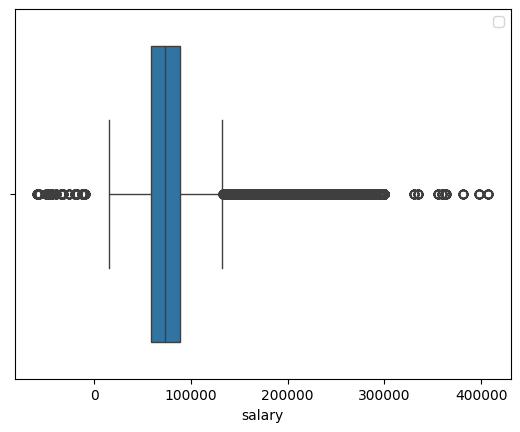

In [138]:
sns.boxplot(data=df_mergeado, x="salary")

plt.legend();

In [139]:
Q1 = df_mergeado['salary'].quantile(0.25)
Q3 = df_mergeado['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [140]:
lower_bound

np.float64(15246.0)

In [141]:
upper_bound

np.float64(132622.0)

In [156]:
def corregir_salarios_negativos(df, columna):
    df[columna] = df[columna].where(df[columna] >= 0, numpy.nan)
    return df

In [165]:
df_mergeado = corregir_salarios_negativos(df_mergeado, 'salary')

SyntaxError: invalid syntax (1480657710.py, line 1)

In [167]:
df_mergeado["salary"].value_counts(dropna=False)

salary
NaN         102740
101933.0       552
62283.0        336
61809.0        336
51573.0        336
             ...  
100295.0        24
28446.0         24
80544.0         24
52194.0         24
50969.0         24
Name: count, Length: 5871, dtype: int64

In [168]:
df_mergeado['salary'].isnull().sum()

np.int64(102740)

In [170]:
df_mergeado['salary'].isnull().mean() * 100

np.float64(25.445809391717848)

In [171]:
df_mergeado.tail(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_month
405622,999982,2018,Diciembre,0,0,0,0.0,0.0,0.0,0.0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,Julio,NaN
405623,999986,2018,Diciembre,0,0,0,0.0,0.0,0.0,0.0,Canada,Ontario,Ottawa,K1F 2R2,Female,Bachelor,46594.0,Married,Nova,8257.01,2018 Promotion,2018,Febrero,NaN


In [175]:
media_salario = (df_mergeado['salary'].median())

In [172]:
print(df_mergeado['salary'].mean())
print(df_mergeado['salary'].median())

79441.62882864926
73523.0


<Axes: >

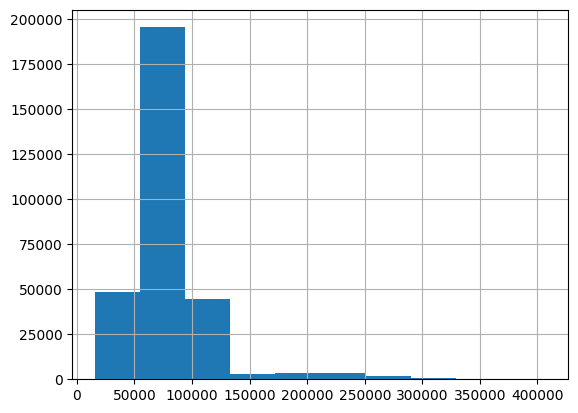

In [173]:
df_mergeado["salary"].hist()

In [176]:
rango_salario = df_mergeado["salary"].max() - df_mergeado["salary"].min()
coeficiente_variacion_salario = (df_mergeado["salary"].std() / media_salario) * 100
print(rango_salario)
print(coeficiente_variacion_salario.round(2))

391619.0
47.2


In [177]:
df_mergeado['salary'] = df_mergeado['salary'].fillna(df_mergeado['salary'].median())

In [179]:
df_mergeado["salary"].value_counts(dropna=False)

salary
73523.0     102788
101933.0       552
61809.0        336
51573.0        336
62283.0        336
             ...  
100295.0        24
28446.0         24
80544.0         24
52194.0         24
50969.0         24
Name: count, Length: 5870, dtype: int64

C:\Users\al101\AppData\Local\Temp\ipykernel_1340\1969673919.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


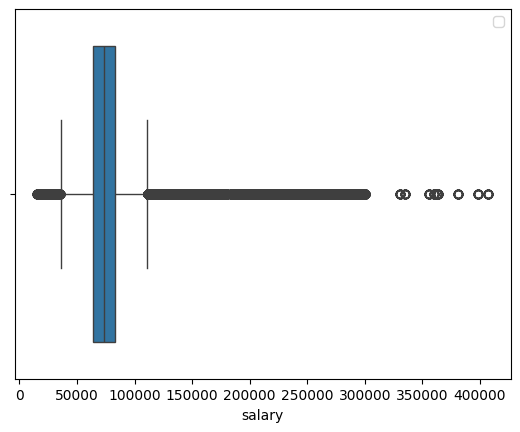

In [180]:
sns.boxplot(data=df_mergeado, x="salary")

plt.legend();

In [181]:
df_mergeado.dtypes

loyalty_number                   int64
year                             int64
month                           object
flights_booked                   int64
flights_with_companions          int64
total_flights                    int64
distance                       float64
points_accumulated             float64
points_redeemed                float64
dollar_cost_points_redeemed    float64
country                         object
province                        object
city                            object
postal_code                     object
gender                          object
education                       object
salary                         float64
marital_status                  object
loyalty_card                    object
clv                            float64
enrollment_type                 object
enrollment_year                  int64
enrollment_month                object
cancellation_month              object
dtype: object

In [182]:
columnas_numericas = ['flights_booked', 'flights_with_companions', 'total_flights', 
                      'distance', 'points_accumulated', 'points_redeemed', 
                      'dollar_cost_points_redeemed', 'salary', 'clv']

df_mergeado[columnas_numericas].describe()

,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,salary,clv
count,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000
mean,4.134050,1.036569,5.170619,1214.460979,124.263761,30.838587,2.495973,77935.585818,7990.864857
std,5.230064,2.080472,6.526858,1434.098521,146.696179,125.758002,10.172033,30076.052460,6863.317160
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15609.000000,1898.010000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64001.000000,3981.780000
50%,1.000000,0.000000,1.000000,525.000000,53.000000,0.000000,0.000000,73523.000000,5776.340000
75%,8.000000,1.000000,10.000000,2342.000000,240.000000,0.000000,0.000000,82940.000000,8937.120000
max,21.000000,11.000000,32.000000,6293.000000,676.500000,876.000000,71.000000,407228.000000,83325.380000


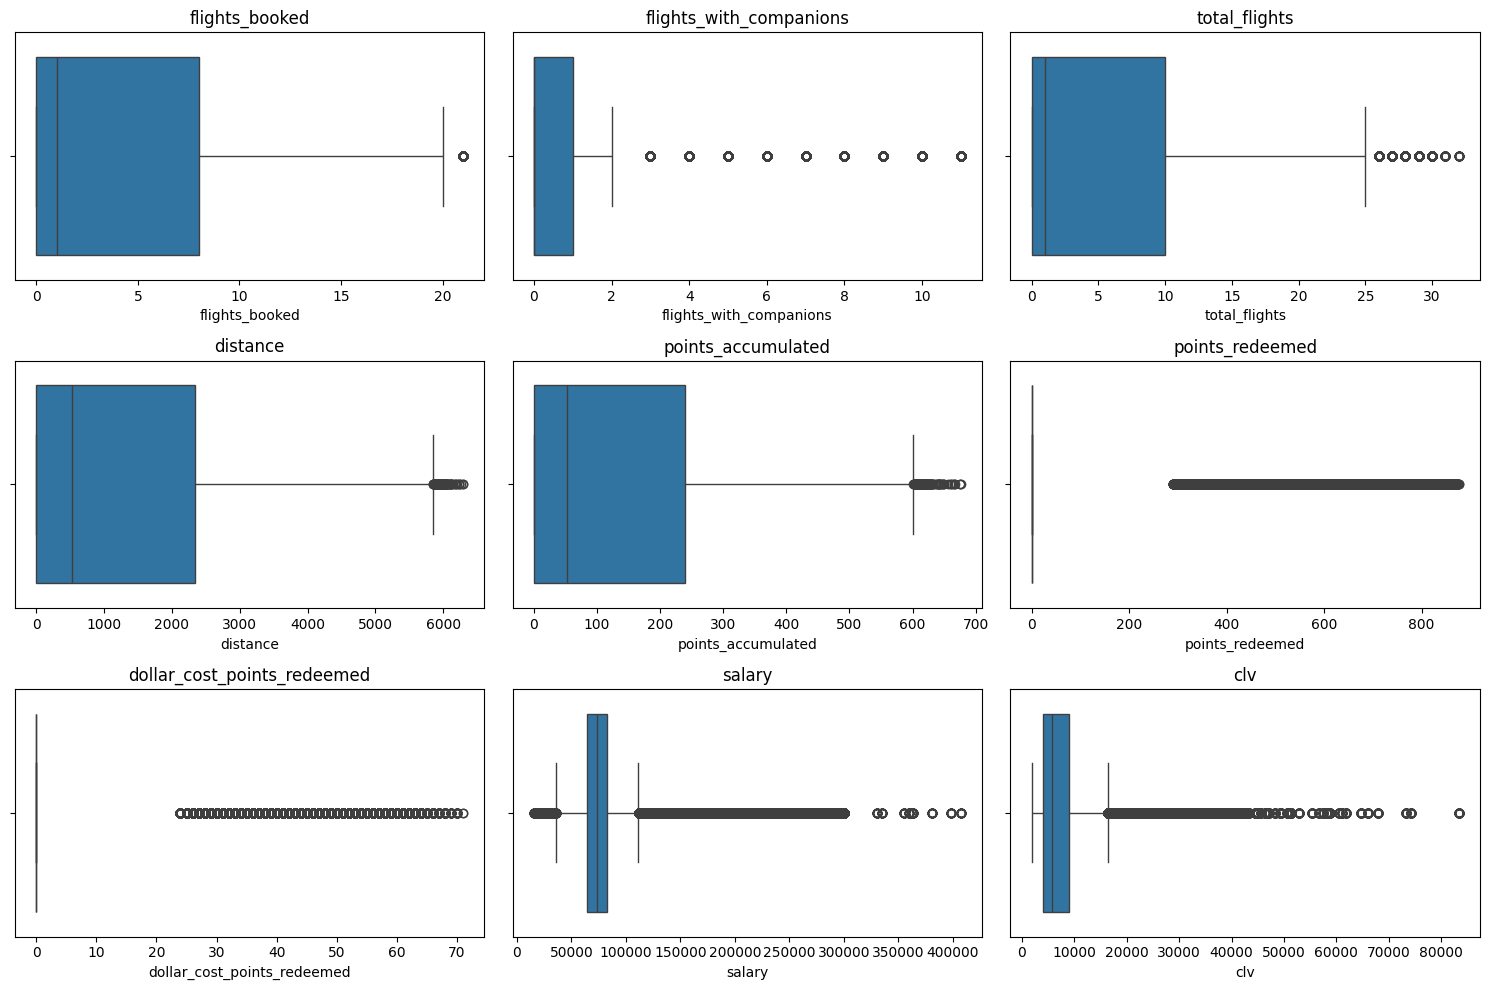

In [183]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=df_mergeado, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

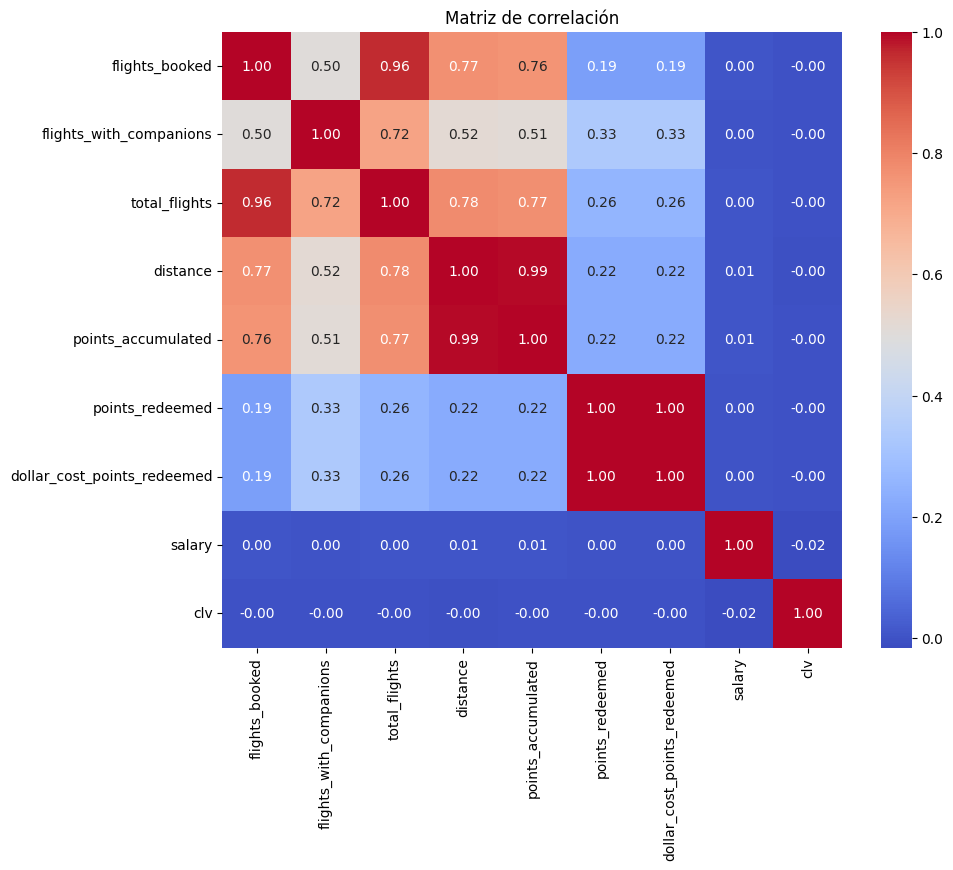

In [184]:
correlacion = df_mergeado[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [185]:
columnas_categoricas = ['gender', 'education', 'marital_status', 
                        'loyalty_card', 'enrollment_type']

for col in columnas_categoricas:
    print(f"\n{col}:")
    print(df_mergeado[col].value_counts())


gender:
gender
Female    202757
Male      201003
Name: count, dtype: int64

education:
education
Bachelor                252567
College                 102260
High School or Below     18915
Doctor                   17731
Master                   12287
Name: count, dtype: int64

marital_status:
marital_status
Married     234845
Single      108153
Divorced     60762
Name: count, dtype: int64

loyalty_card:
loyalty_card
Star      183745
Nova      136883
Aurora     83132
Name: count, dtype: int64

enrollment_type:
enrollment_type
Standard          380419
2018 Promotion     23341
Name: count, dtype: int64


In [ ]:
df_mergeado['']

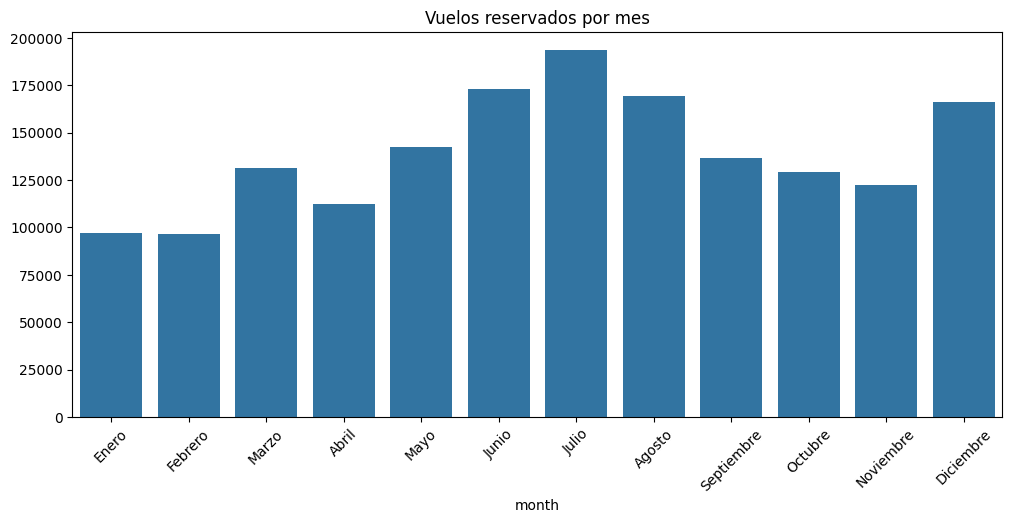

In [189]:
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
               'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

vuelos_mes = df_mergeado.groupby('month')['flights_booked'].sum().reindex(orden_meses)

plt.figure(figsize=(12, 5))
sns.barplot(x=vuelos_mes.index, y=vuelos_mes.values)
plt.title('Vuelos reservados por mes')
plt.xticks(rotation=45)
plt.show()

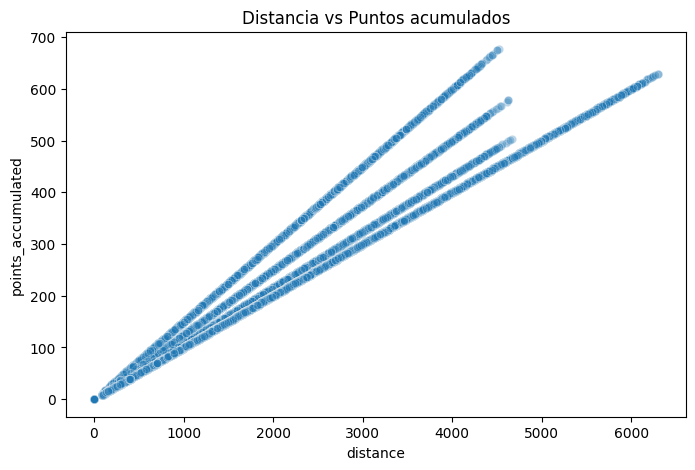

In [190]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_mergeado, x='distance', y='points_accumulated', alpha=0.3)
plt.title('Distancia vs Puntos acumulados')
plt.show()

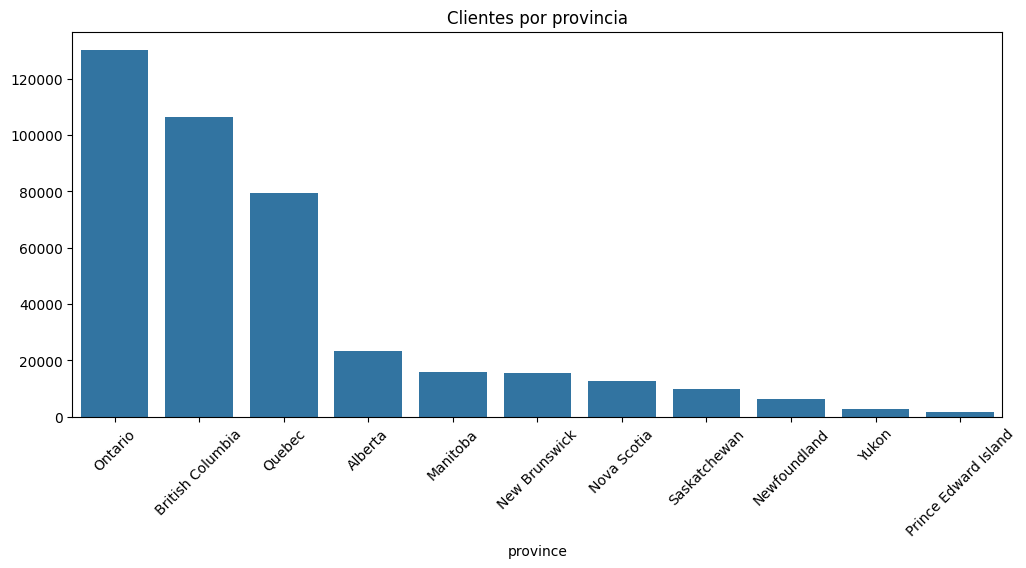

In [191]:
clientes_provincia = df_mergeado['province'].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=clientes_provincia.index, y=clientes_provincia.values)
plt.title('Clientes por provincia')
plt.xticks(rotation=45)
plt.show()

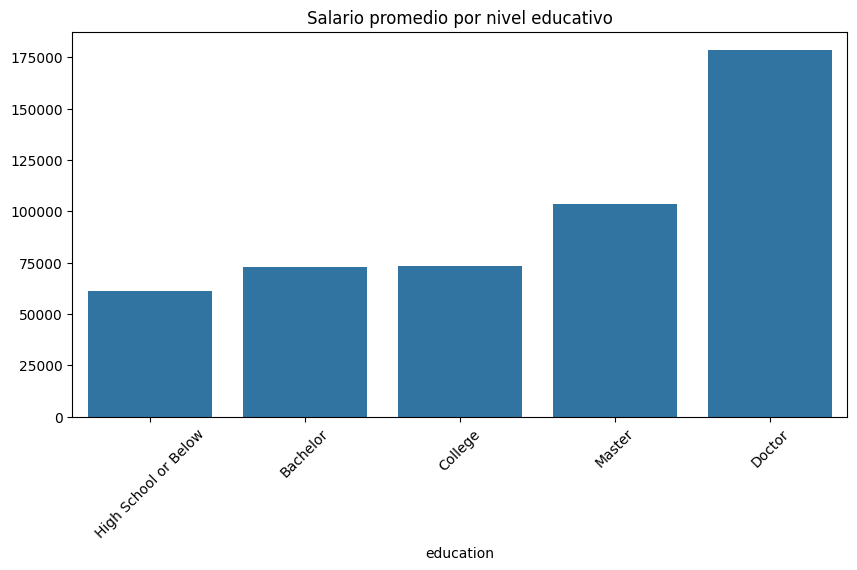

In [192]:
salario_educacion = df_mergeado.groupby('education')['salary'].mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=salario_educacion.index, y=salario_educacion.values)
plt.title('Salario promedio por nivel educativo')
plt.xticks(rotation=45)
plt.show()

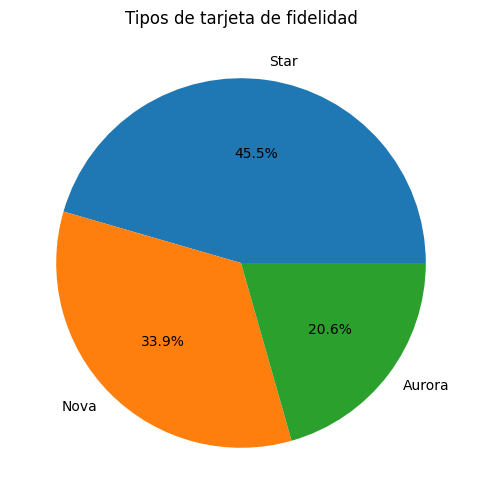

In [193]:
plt.figure(figsize=(6, 6))
df_mergeado['loyalty_card'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Tipos de tarjeta de fidelidad')
plt.ylabel('')
plt.show()

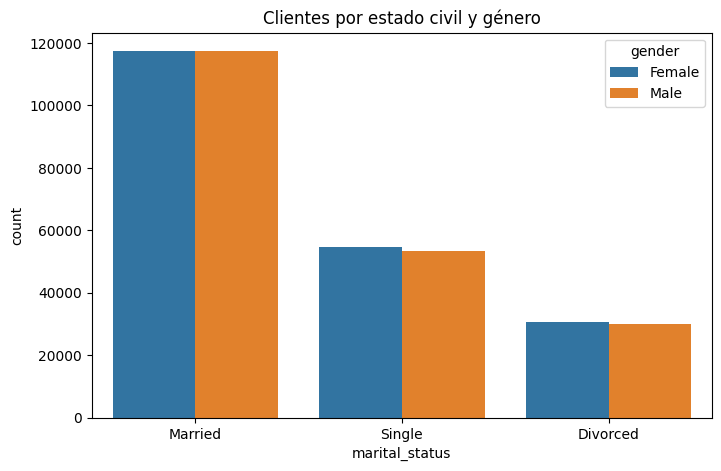

In [194]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_mergeado, x='marital_status', hue='gender')
plt.title('Clientes por estado civil y género')
plt.show()

In [195]:
df_fase4 = df_mergeado[['flights_booked', 'education']].copy()

In [196]:
descriptivo = df_fase4.groupby('education')['flights_booked'].agg(
    media='mean',
    mediana='median',
    desviacion_std='std',
    minimo='min',
    maximo='max',
    count='count'
).round(2)

print(descriptivo)

                      media  mediana  desviacion_std  minimo  maximo   count
education                                                                   
Bachelor               4.11      1.0            5.22       0      21  252567
College                4.17      1.0            5.25       0      21  102260
Doctor                 4.18      1.0            5.26       0      21   17731
High School or Below   4.18      1.0            5.24       0      21   18915
Master                 4.20      1.0            5.21       0      21   12287
